In [18]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

In [21]:
df_cpi = pd.read_csv('data/sticky_price_cpi.csv')
df_cpi['observation_date'] = pd.to_datetime(df_cpi['observation_date'])
df_cpi.set_index('observation_date', inplace=True)
df_cpi.sort_index(inplace=True)

In [22]:
df_cpi

,CORESTICKM159SFRBATL
observation_date,
1968-01-01,3.651861
1968-02-01,3.673819
1968-03-01,4.142164
1968-04-01,4.155828
1968-05-01,4.088245
...,...
2024-11-01,3.876177
2024-12-01,3.746553
2025-01-01,3.625276


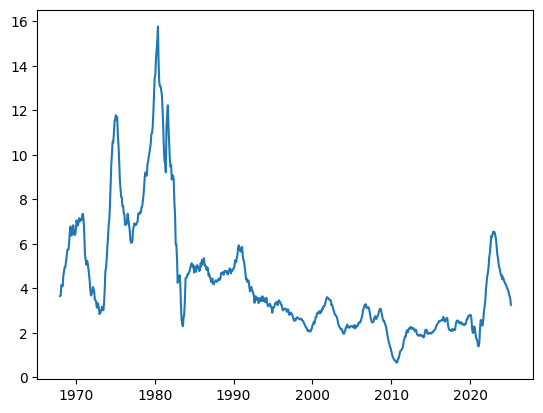

In [23]:
plt.plot(df_cpi['CORESTICKM159SFRBATL'])

In [15]:

df_cpi['CPI_pct_change'] = df_cpi['CPIAUCSL'].pct_change() * 100

In [16]:
for i in range(1, 13):
    df_cpi[f'CPI_lag_{i}'] = df_cpi['CPIAUCSL'].shift(i)
    df_cpi[f'CPI_lag_pct_{i}'] = df_cpi['CPI_pct_change'].shift(i)

In [17]:
df_cpi.tail()

,CPIAUCSL,CPI_pct_change,CPI_lag_1,CPI_lag_pct_1,CPI_lag_2,CPI_lag_pct_2,CPI_lag_3,CPI_lag_pct_3,CPI_lag_4,CPI_lag_pct_4,...,CPI_lag_8,CPI_lag_pct_8,CPI_lag_9,CPI_lag_pct_9,CPI_lag_10,CPI_lag_pct_10,CPI_lag_11,CPI_lag_pct_11,CPI_lag_12,CPI_lag_pct_12
observation_date,,,,,,,,,,,,,,,,,,,,,
2024-11-01,316.449,0.280450,315.564,0.226456,314.851,0.229204,314.131,0.180185,313.566,0.138919,...,312.107,0.348850,311.022,0.396392,309.794,0.343013,308.735,0.210330,308.087,0.141068
2024-12-01,317.603,0.364672,316.449,0.280450,315.564,0.226456,314.851,0.229204,314.131,0.180185,...,313.016,0.291246,312.107,0.348850,311.022,0.396392,309.794,0.343013,308.735,0.210330
2025-01-01,319.086,0.466935,317.603,0.364672,316.449,0.280450,315.564,0.226456,314.851,0.229204,...,313.140,0.039615,313.016,0.291246,312.107,0.348850,311.022,0.396392,309.794,0.343013
2025-02-01,319.775,0.215929,319.086,0.466935,317.603,0.364672,316.449,0.280450,315.564,0.226456,...,313.131,-0.002874,313.140,0.039615,313.016,0.291246,312.107,0.348850,311.022,0.396392
2025-03-01,319.615,-0.050035,319.775,0.215929,319.086,0.466935,317.603,0.364672,316.449,0.280450,...,313.566,0.138919,313.131,-0.002874,313.140,0.039615,313.016,0.291246,312.107,0.348850
